# Imports

In [9]:
from controller import Controller
from eom import EOM
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_are

# Set up EOM

In [10]:
eom = EOM()

# Params
mass = 0.5  # kg
inertia = np.diag([0.0023, 0.0023, 0.0040])  # kg*m^2
leg_length = 0.175  # m
k_f_val = 62.8 # Slope of thrust/motor torque curve (linear)
k_yaw_val = 1.0 # Yaw torque constant, default 1.0

eom.set_parameters(mass, inertia, leg_length, k_f_val, k_yaw_val)
eom.setup()

# Define LQR function

In [11]:
def lqr(A: np.ndarray, B: np.ndarray, Q: np.ndarray, R: np.ndarray) -> np.ndarray:
    """Compute the LQR gain matrix K.

    Args:
        A (np.ndarray): State matrix.
        B (np.ndarray): Input matrix.
        Q (np.ndarray): State cost matrix.
        R (np.ndarray): Input cost matrix.

    Returns:
        np.ndarray: LQR gain matrix K.
    """
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ B.T @ P
    return K

# Create controller object

In [12]:
# Params
dt = 0.0005  # time step, s
t_max = 10.0 # total simulation time, s
max_motor_torque = 0.0851209 # N*m
x0 = np.zeros(12)  # initial state
u0 = np.array([eom.tau_e, eom.tau_e, eom.tau_e, eom.tau_e])  # initial input (hover)

controller = Controller(eom=eom, dt=dt, t_max=t_max, max_motor_torque=max_motor_torque, x0=x0, u0=u0)

# Define gain matrix K

In [13]:
# position (p_x, p_y, p_z)
q_pos = 2.0 * 1e0
# angles (psi, theta, phi)
q_ang = 1.0 * 1e-2
# linear velocities (v_x, v_y, v_z)
q_vel = 2.0 * 1e0
# angular velocities (w_x, w_y, w_z)
q_omega = 1.0 * 1e-2

Q = np.diag([
    q_pos, q_pos, q_pos,      # p_x, p_y, p_z
    q_ang, q_ang, q_ang,      # psi, theta, phi
    q_vel, q_vel, q_vel,      # v_x, v_y, v_z
    q_omega, q_omega, q_omega # w_x, w_y, w_z
])

R = 1e-4 * np.eye(4)  # penalize large motor deviations a bit
K = lqr(eom.A_num, eom.B_num, Q, R)
controller.setK(K)


# Performance Goal 1: Hover at 1 meter

## Control loop

In [14]:
t = 0.0
x = x0
x_des = np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])  # desired state: hover at 1 meter
while t < t_max:
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]
    # print(controller.inputs[-1])

## Plots

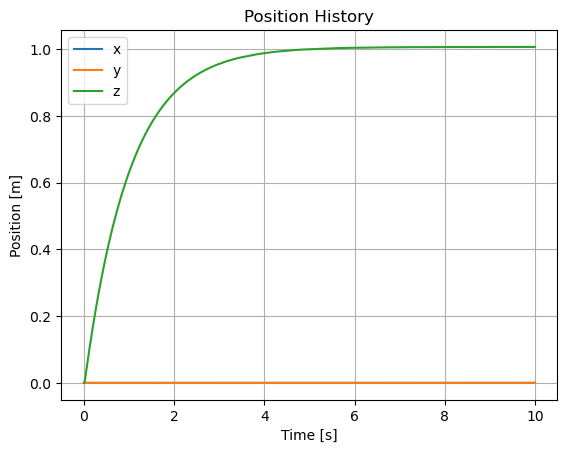

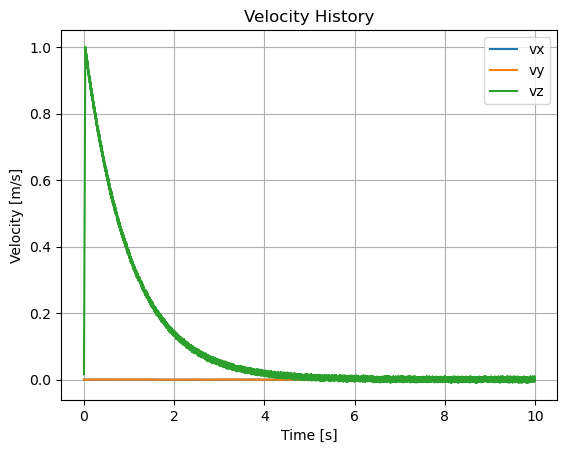

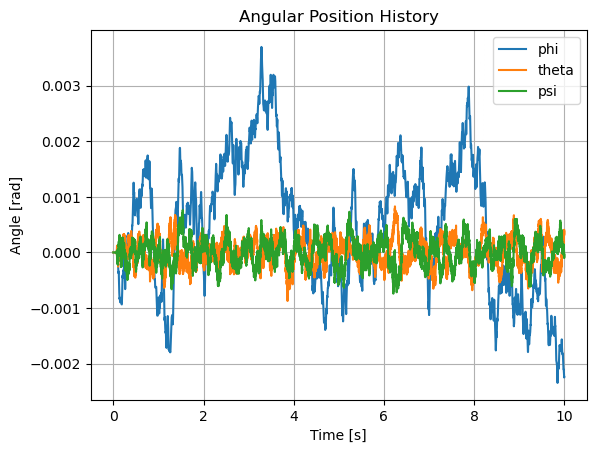

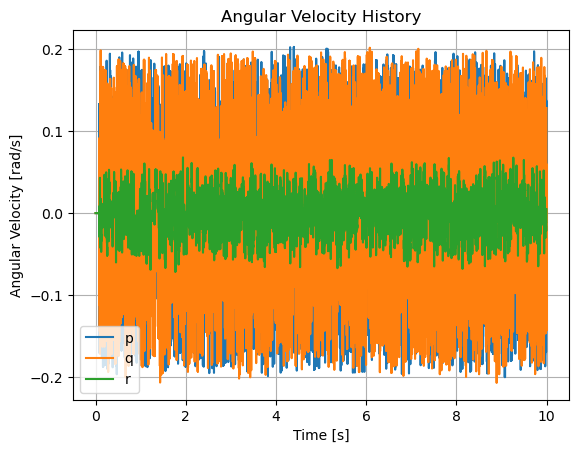

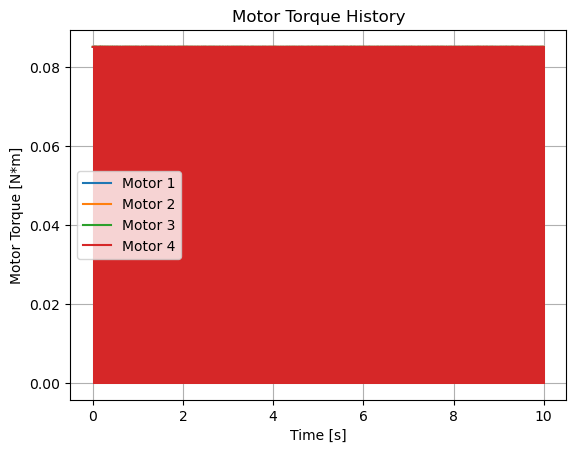

In [15]:
controller.plot_position()
controller.plot_velocity()
controller.plot_attitude()
controller.plot_angular_velocity()
controller.plot_motor_torques()
controller.plot_propeller_rpm()

# Performance Goal 2: Circular motion

In [ ]:
t = 0.0
x = x0
x_des = ...
while t < t_max:
    controller.step(t, x, x_des)
    t += dt
    x = controller.states[-1]

In [ ]:
# Plot